# Exploratory Data Analysis (EDA) — Ozon User LTV (Этапы 1 - 8)

Данный ноутбук содержит полный исследовательский анализ логов OZON LTV:
1. **Аудит данных и логики витрины**
2. **Временная структура, Сезонность и Праздничные Всплески (Новый Год, 11.11, 23 Февраля, 8 Марта)**
3. **Анализ таргета по всем 4-м фолдам (Zero inflation, Drift, Концентрация)**
4. **Матрица покупательских состояний и авторегрессионные бейзлайны по RMSLE**
5. **RFM-анализ, Recency Поисков/Корзин и конверсия неактивных пользователей**
6. **Воронка конверсии (Поиск -> Корзина -> Заказ) и сегментация каналов (Search vs Catalog)**
7. **Динамика пользователя и ускорение (30d vs 30_60d)**
8. **Анализ признаков перед моделированием (Спирмен, Мультиколлинеарность, Train-Val Drift)**

Код предобработки вынесен в модуль [`src/data.py`](file:///c:/Users/egorg/Documents/OZON_ECUP/src/data.py).

In [9]:
from datetime import date, timedelta
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, ks_2samp
from sklearn.metrics import roc_auc_score

from src.data import read_fold, generate_cv_anchor_dates, FEATURES_DIR

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

## Этап 1. Аудит данных и корректности витрины

In [10]:
data = pl.read_parquet("data/train.parquet")
dup_count = data.select(pl.struct(["user_id", "event_date"]).is_duplicated()).to_series().sum()
null_sum = sum([data[c].null_count() for c in data.columns])
ord_match = (data["to_ord"] == (data["search_to_ord"] + data["cat_to_ord"])).mean() * 100
gmv_match = (data["gmv"].round(2) == (data["gmv_search"] + data["gmv_cat"]).round(2)).mean() * 100
print(f"Всего строк: {len(data):,}, Дубликатов: {dup_count}, Null: {null_sum}")
print(f"Декомпозиция заказов: {ord_match:.2f}% match, GMV: {gmv_match:.2f}% match")

Всего строк: 30,631,006, Дубликатов: 0, Null: 0
Декомпозиция заказов: 100.00% match, GMV: 100.00% match


## Этап 2. Сезонность и Праздничные всплески (Новый Год, 11.11, 23 Февраля, 8 Марта)

Анализ суточной активности DAU и GMV на юзера с разметкой главных праздников.

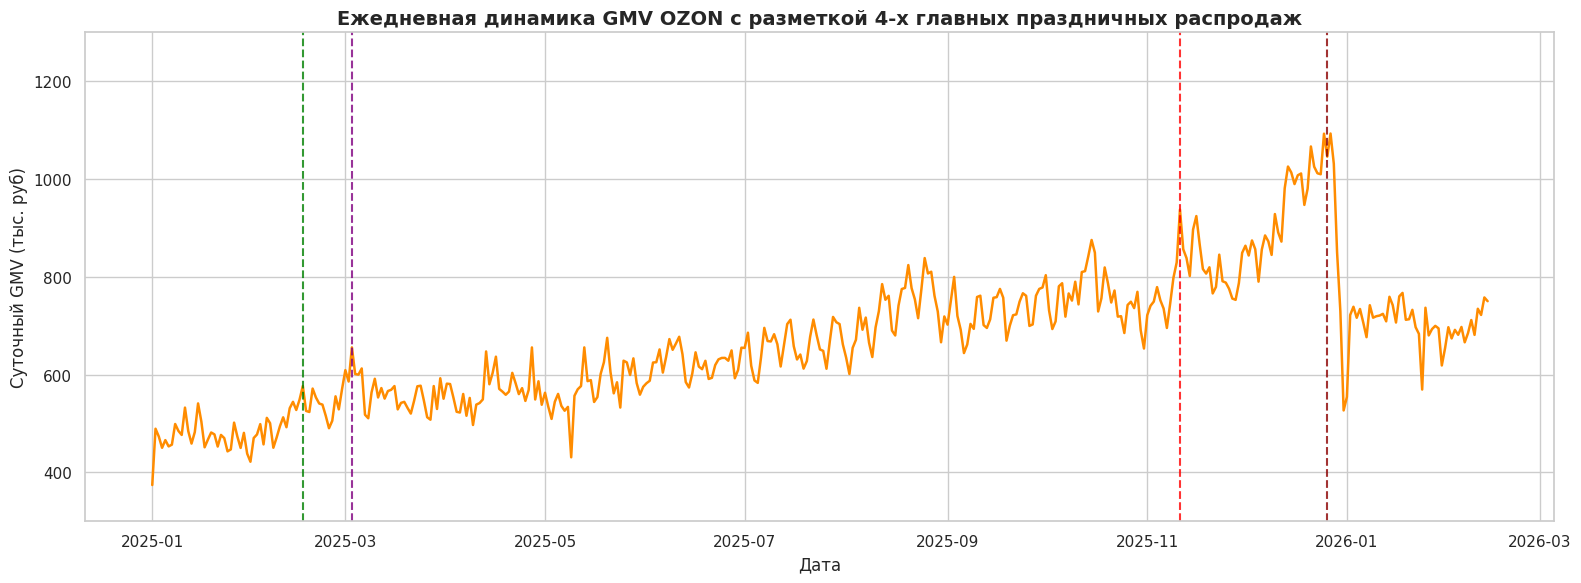

In [11]:
daily_agg = (
    data.group_by("event_date")
    .agg(
        pl.len().alias("dau"),
        pl.sum("gmv").alias("gmv_sum"),
        pl.sum("to_ord").alias("total_orders"),
    )
    .with_columns((pl.col("gmv_sum") / pl.col("dau")).alias("gmv_per_dau"))
    .sort("event_date")
)

daily_pd = daily_agg.to_pandas()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_pd["event_date"], daily_pd["gmv_sum"] / 1e3, color="darkorange", linewidth=1.8, label="Суточный GMV (тыс. руб)")
ax.set_title("Ежедневная динамика GMV OZON с разметкой 4-х главных праздничных распродаж", fontsize=14, fontweight="bold")
ax.set_ylabel("Суточный GMV (тыс. руб)")
ax.set_xlabel("Дата")

# Разметка ключевых праздников
holidays = [
    (date(2025, 2, 16), "23 Февраля (Пик подарков)", "green"),
    (date(2025, 3, 3), "8 Марта (Весенний пик)", "purple"),
    (date(2025, 11, 11), "11.11 Всемирная распродажа", "red"),
    (date(2025, 12, 26), "Новый Год (Абсолютный пик)", "darkred")
]

for h_date, h_name, h_color in holidays:
    ax.axvline(h_date, color=h_color, linestyle="--", linewidth=1.5, alpha=0.8)
    # Найти GMV на эту дату
    val = daily_pd[daily_pd["event_date"] == h_date]["gmv_sum"].values
    if len(val) > 0:
        y_val = val[0] / 1e3
        ax.annotate(f"{h_name}\n({y_val:.0f}k руб)", (h_date, y_val),
                    xytext=(0, 25), textcoords="offset points", ha="center",
                    arrowprops=dict(arrowstyle="->", color=h_color, lw=1.2),
                    fontweight="bold", color=h_color)

ax.set_ylim(300, 1300)
plt.tight_layout()
plt.show()

## Этап 3. Анализ таргета по всем 4 фолдам

In [12]:
fold_dfs = [read_fold(FEATURES_DIR, f"fold_{i:02d}") for i in range(4)]
f3 = fold_dfs[3]
target_bin = (f3["target"].to_numpy() > 0).astype(int)
f3_with_bin = f3.with_columns(pl.Series("target_bin", target_bin))

folds_summary = []
for i in range(4):
    tgt = fold_dfs[i]["target"].to_numpy()
    folds_summary.append({
        "fold": f"fold_{i:02d}",
        "anchor": fold_dfs[i]["anchor_date"][0],
        "zero_rate_%": round((tgt == 0).mean() * 100, 2),
        "mean": round(tgt.mean(), 2),
        "median": round(np.median(tgt), 2),
        "total_gmv": round(tgt.sum(), 2),
    })
print(pl.DataFrame(folds_summary))

shape: (4, 6)
┌─────────┬────────────┬─────────────┬────────┬────────┬───────────┐
│ fold    ┆ anchor     ┆ zero_rate_% ┆ mean   ┆ median ┆ total_gmv │
│ ---     ┆ ---        ┆ ---         ┆ ---    ┆ ---    ┆ ---       │
│ str     ┆ date       ┆ f64         ┆ f64    ┆ f64    ┆ f64       │
╞═════════╪════════════╪═════════════╪════════╪════════╪═══════════╡
│ fold_00 ┆ 2025-12-03 ┆ 42.45       ┆ 110.04 ┆ 14.65  ┆ 2.7509e7  │
│ fold_01 ┆ 2025-12-17 ┆ 44.03       ┆ 99.23  ┆ 11.53  ┆ 2.4808e7  │
│ fold_02 ┆ 2025-12-31 ┆ 46.45       ┆ 84.58  ┆ 7.58   ┆ 2.1144e7  │
│ fold_03 ┆ 2026-01-14 ┆ 45.93       ┆ 84.03  ┆ 7.89   ┆ 2.1009e7  │
└─────────┴────────────┴─────────────┴────────┴────────┴───────────┘


## Этап 4. Переходы состояний и Авторегрессионные бейзлайны

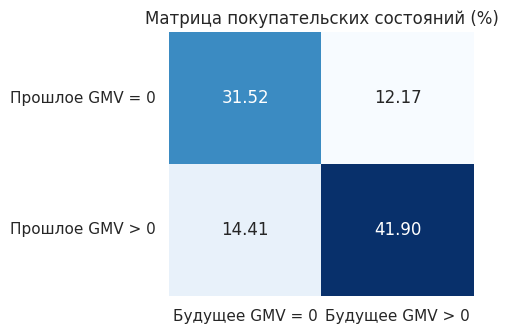

In [13]:
past = f3["gmv_sum_30d"].to_numpy()
future = f3["target"].to_numpy()
trans_matrix = np.array([
    [((past == 0) & (future == 0)).sum(), ((past == 0) & (future > 0)).sum()],
    [((past > 0) & (future == 0)).sum(), ((past > 0) & (future > 0)).sum()]
])
trans_pct = trans_matrix / len(future) * 100
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.heatmap(trans_pct, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Будущее GMV = 0", "Будущее GMV > 0"],
            yticklabels=["Прошлое GMV = 0", "Прошлое GMV > 0"])
plt.title("Матрица покупательских состояний (%)")
plt.tight_layout()
plt.show()

## Этап 5. RFM-анализ и влияние корзины на активных юзеров

shape: (4, 4)
┌───────────────────────┬───────┬──────────────┬─────────────────┐
│ cart_bin              ┆ users ┆ P_target_pos ┆ mean_future_gmv │
│ ---                   ┆ ---   ┆ ---          ┆ ---             │
│ str                   ┆ u32   ┆ f64          ┆ f64             │
╞═══════════════════════╪═══════╪══════════════╪═════════════════╡
│ 0. No cart (0)        ┆ 18707 ┆ 0.381087     ┆ 33.993747       │
│ 1. Small cart (1-3)   ┆ 40843 ┆ 0.507113     ┆ 46.758596       │
│ 2. Medium cart (4-10) ┆ 51965 ┆ 0.660598     ┆ 78.330024       │
│ 3. Large cart (>10)   ┆ 75973 ┆ 0.831796     ┆ 180.539773      │
└───────────────────────┴───────┴──────────────┴─────────────────┘


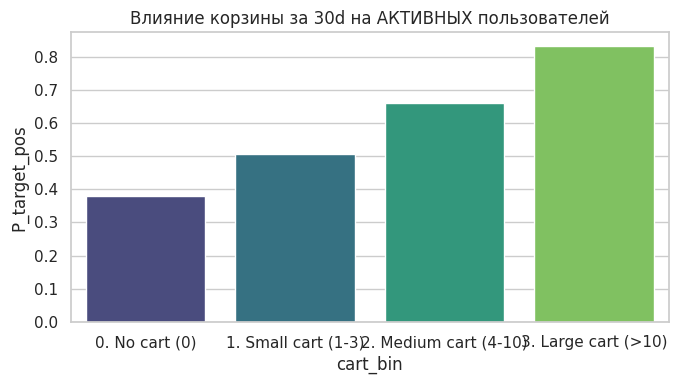

In [14]:
active_df = f3.filter(pl.col("gmv_sum_90d") > 0).with_columns(pl.Series("target_bin", target_bin[f3["gmv_sum_90d"].to_numpy() > 0]))
def get_cart_bin(c):
    if c == 0: return "0. No cart (0)"
    elif c <= 3: return "1. Small cart (1-3)"
    elif c <= 10: return "2. Medium cart (4-10)"
    else: return "3. Large cart (>10)"

act_cart_stats = (
    active_df.with_columns(pl.Series("cart_bin", [get_cart_bin(c) for c in active_df["to_cart_sum_30d"]]))
    .group_by("cart_bin")
    .agg(pl.len().alias("users"), pl.col("target_bin").mean().alias("P_target_pos"), pl.col("target").mean().alias("mean_future_gmv"))
    .sort("cart_bin")
)
print(act_cart_stats)
fig, ax1 = plt.subplots(figsize=(7, 4))
sns.barplot(data=act_cart_stats.to_pandas(), x="cart_bin", y="P_target_pos", ax=ax1, palette="viridis", hue="cart_bin", legend=False)
ax1.set_title("Влияние корзины за 30d на АКТИВНЫХ пользователей")
plt.tight_layout()
plt.show()

## Этап 6. Воронка конверсии и сегментация каналов (Search vs Catalog)

In [15]:
anchor = date(2026, 1, 14)
hist_90 = data.filter(pl.col("event_date").is_between(anchor - timedelta(days=89), anchor))
chan_agg = hist_90.group_by("user_id").agg(pl.sum("search_to_ord").alias("search_ords_90d"), pl.sum("cat_to_ord").alias("cat_ords_90d"))
df_chan = f3.join(chan_agg, on="user_id", how="left").with_columns(pl.col("search_ords_90d").fill_null(0), pl.col("cat_ords_90d").fill_null(0), pl.Series("target_bin", target_bin))

def get_channel(s, c):
    if s > 0 and c == 0: return "1. Search Only"
    elif s == 0 and c > 0: return "2. Catalog Only"
    elif s > 0 and c > 0: return "3. Both Channels"
    else: return "4. Neither Channel (0 orders)"

chan_stats = df_chan.with_columns(pl.Series("channel_seg", [get_channel(s, c) for s, c in zip(df_chan["search_ords_90d"], df_chan["cat_ords_90d"])])).group_by("channel_seg").agg(pl.len().alias("users"), pl.col("target_bin").mean().alias("P_target_pos"), pl.col("target").mean().alias("mean_future_gmv")).sort("channel_seg")
print(chan_stats)

shape: (4, 4)
┌───────────────────────────────┬────────┬──────────────┬─────────────────┐
│ channel_seg                   ┆ users  ┆ P_target_pos ┆ mean_future_gmv │
│ ---                           ┆ ---    ┆ ---          ┆ ---             │
│ str                           ┆ u32    ┆ f64          ┆ f64             │
╞═══════════════════════════════╪════════╪══════════════╪═════════════════╡
│ 1. Search Only                ┆ 140536 ┆ 0.628679     ┆ 88.486889       │
│ 2. Catalog Only               ┆ 2686   ┆ 0.397617     ┆ 32.452826       │
│ 3. Both Channels              ┆ 44266  ┆ 0.811978     ┆ 176.421827      │
│ 4. Neither Channel (0 orders) ┆ 62512  ┆ 0.156802     ┆ 10.818085       │
└───────────────────────────────┴────────┴──────────────┴─────────────────┘


## Этапы 7-8. Динамика, Спирмен и Train-Val Drift

In [16]:
feature_cols = [c for c in f3.columns if c not in ["anchor_date", "user_id", "target"]]
tgt3 = f3["target"].to_numpy()
spearman_scores = []
for c in feature_cols:
    vals = f3[c].to_numpy()
    score_vals = -vals if c.startswith("days_since_") else vals
    rho, _ = spearmanr(score_vals, tgt3)
    spearman_scores.append((c, round(rho, 4)))
spearman_df = pl.DataFrame(spearman_scores, schema=["feature", "spearman_rho"], orient="row").sort("spearman_rho", descending=True)
print("Топ-10 признаков по Спирмену с Target GMV:")
print(spearman_df.head(10))

f2 = fold_dfs[2]
drift_scores = []
for c in feature_cols:
    ks_stat, _ = ks_2samp(f2[c].to_numpy(), f3[c].to_numpy())
    drift_scores.append((c, round(ks_stat, 4)))
drift_df = pl.DataFrame(drift_scores, schema=["feature", "KS_statistic"], orient="row").sort("KS_statistic", descending=True)
print("\nТоп признаков с наибольшим дрифтом (KS statistic между fold_02 и fold_03):")
print(drift_df.head(10))

Топ-10 признаков по Спирмену с Target GMV:
shape: (10, 2)
┌─────────────────┬──────────────┐
│ feature         ┆ spearman_rho │
│ ---             ┆ ---          │
│ str             ┆ f64          │
╞═════════════════╪══════════════╡
│ to_ord_sum_90d  ┆ 0.6368       │
│ to_ord_sum_60d  ┆ 0.6225       │
│ gmv_sum_90d     ┆ 0.6094       │
│ gmv_sum_60d     ┆ 0.5974       │
│ to_ord_sum_30d  ┆ 0.5752       │
│ to_ord_max_90d  ┆ 0.5653       │
│ to_ord_max_60d  ┆ 0.562        │
│ to_ord_mean_90d ┆ 0.562        │
│ gmv_sum_30d     ┆ 0.5567       │
│ to_ord_std_90d  ┆ 0.5545       │
└─────────────────┴──────────────┘


MemoryError: Unable to allocate 3.81 MiB for an array with shape (500000,) and data type float64